In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:

# Set random seeds
tf.random.set_seed(42)
np.random.seed(42)


In [3]:

# Constants
IMAGE_SIZE = 16
BATCH_SIZE = 50
EPOCHS = 5
LEARNING_RATE = 0.1

In [4]:

print("Loading MNIST dataset...")

# Load and preprocess data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

x_train = tf.image.resize(x_train, [IMAGE_SIZE, IMAGE_SIZE]).numpy()
x_test = tf.image.resize(x_test, [IMAGE_SIZE, IMAGE_SIZE]).numpy()

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

Loading MNIST dataset...
Training data shape: (60000, 16, 16, 1)
Test data shape: (10000, 16, 16, 1)


In [5]:

# ====================== REGULAR MODEL ======================

print("\n" + "="*60)
print("TRAINING MODEL ON REGULAR DATA")
print("="*60)

model_regular = models.Sequential([
    layers.Conv2D(16, kernel_size=5, padding='same', activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1)),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(32, kernel_size=5, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])


TRAINING MODEL ON REGULAR DATA


c:\Users\Admin\AppData\Roaming\uv\python\cpython-3.12.13-windows-x86_64-none\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model_regular.compile(
    optimizer=optimizers.SGD(learning_rate=LEARNING_RATE),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [7]:
history_regular = model_regular.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.9184 - loss: 0.2704 - val_accuracy: 0.9720 - val_loss: 0.0874
Epoch 2/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.9759 - loss: 0.0809 - val_accuracy: 0.9796 - val_loss: 0.0599
Epoch 3/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9819 - loss: 0.0601 - val_accuracy: 0.9831 - val_loss: 0.0495
Epoch 4/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9854 - loss: 0.0491 - val_accuracy: 0.9851 - val_loss: 0.0433
Epoch 5/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9875 - loss: 0.0418 - val_accuracy: 0.9867 - val_loss: 0.0404


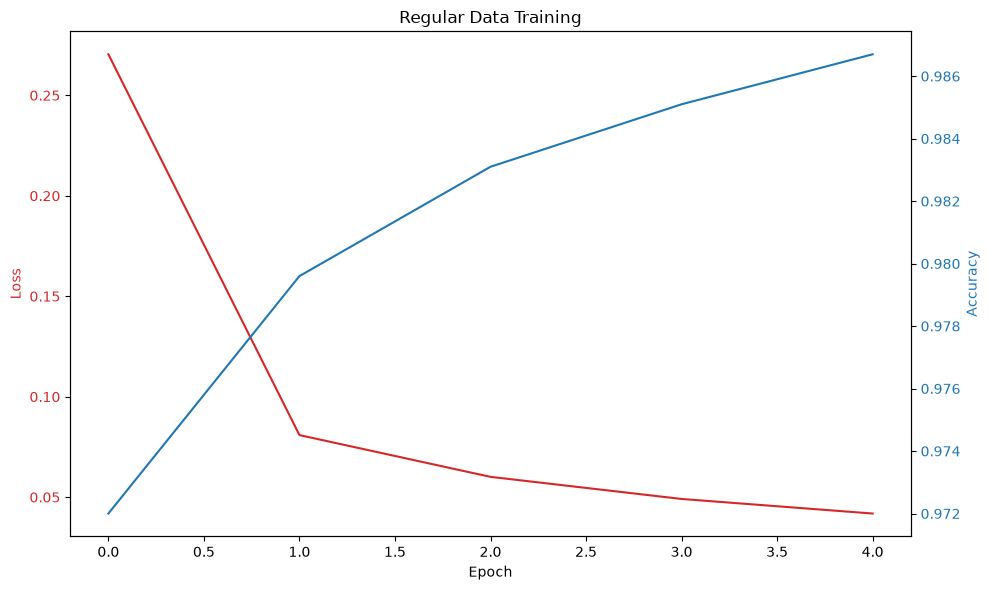

In [8]:

# Plot results
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(history_regular.history['loss'], color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.plot(history_regular.history['val_accuracy'], color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
plt.title('Regular Data Training')
plt.tight_layout()
plt.show()


In [9]:

print("\n" + "="*60)
print("TRAINING MODEL ON ROTATED/AUGMENTED DATA")
print("="*60)


TRAINING MODEL ON ROTATED/AUGMENTED DATA


In [10]:

# ====================== ROTATED MODEL ======================


datagen_rotate = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

In [11]:


train_generator = datagen_rotate.flow(
    x_train, y_train, 
    batch_size=BATCH_SIZE,
    seed=42
)


In [12]:
model_rotated = models.Sequential([
    layers.Conv2D(16, kernel_size=5, padding='same', activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1)),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(32, kernel_size=5, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])


In [13]:

model_rotated.compile(
    optimizer=optimizers.SGD(learning_rate=LEARNING_RATE),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)


In [17]:

history_rotated = model_rotated.fit(
    train_generator,
    steps_per_epoch=len(x_train) // BATCH_SIZE,    
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

ImportError: This requires the scipy module. You can install it via `pip install scipy`

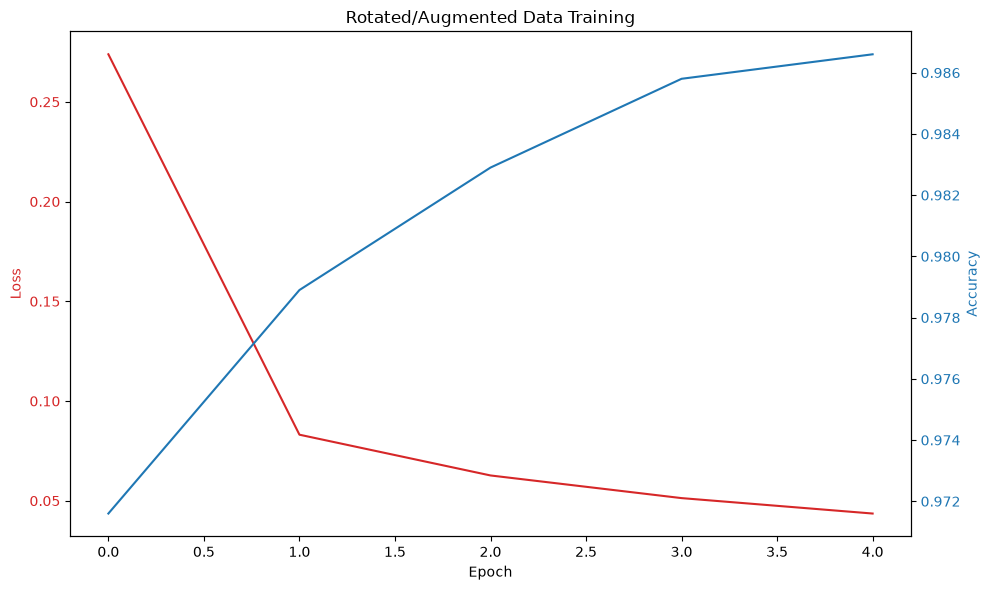

In [ ]:
# Plot results
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(history_rotated.history['loss'], color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.plot(history_rotated.history['val_accuracy'], color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
plt.title('Rotated/Augmented Data Training')
plt.tight_layout()
plt.show()

In [ ]:

# ====================== EVALUATION ======================

print("\n" + "="*60)
print("FINAL EVALUATION ON ROTATED TEST SET")
print("="*60)

loss_reg, acc_reg = model_regular.evaluate(x_test, y_test, verbose=0)
print(f"Regular Model Accuracy : {acc_reg:.4f}")

loss_rot, acc_rot = model_rotated.evaluate(x_test, y_test, verbose=0)
print(f"Rotated Model Accuracy: {acc_rot:.4f}")


FINAL EVALUATION ON ROTATED TEST SET
Regular Model Accuracy : 0.9879
Rotated Model Accuracy: 0.9866



Misclassified samples by Regular Model:


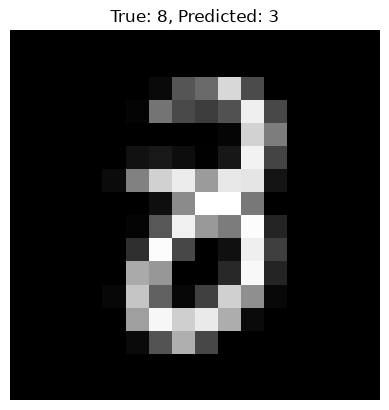

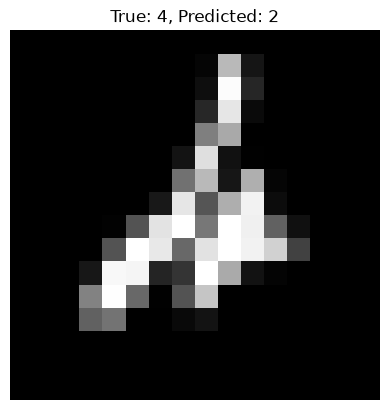

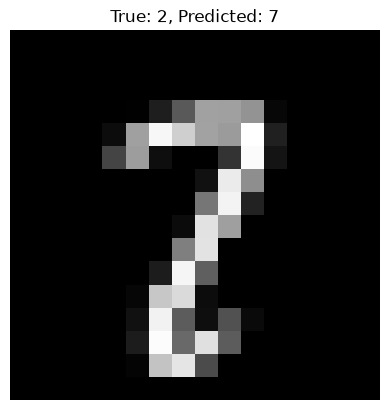

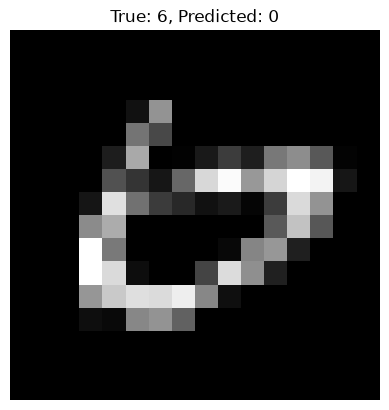

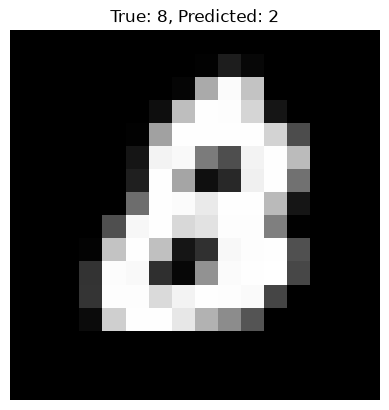


Misclassified samples by Rotated Model:


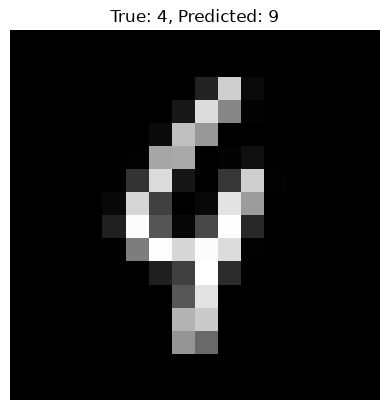

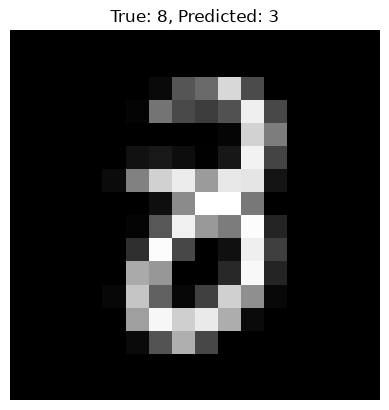

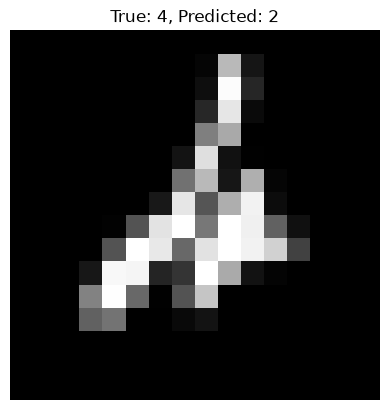

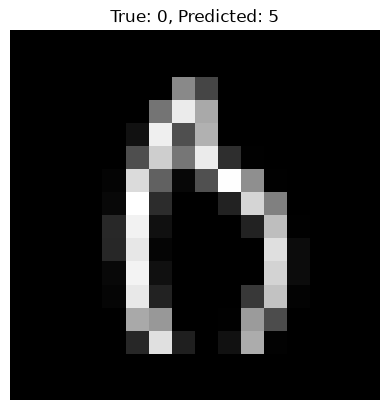

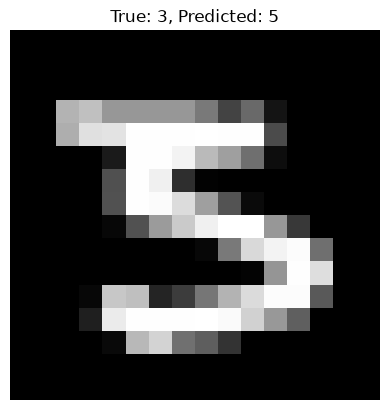


Models saved successfully!
The model trained with rotation performs much better on rotated test images.


In [ ]:







# ====================== MISCLASSIFIED SAMPLES ======================

print("\nMisclassified samples by Regular Model:")
predictions = model_regular.predict(x_test, verbose=0)
pred_labels = np.argmax(predictions, axis=1)

count = 0
for i in range(len(x_test)):
    if pred_labels[i] != y_test[i]:
        plt.imshow(x_test[i].reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
        plt.title(f'True: {y_test[i]}, Predicted: {pred_labels[i]}')
        plt.axis('off')
        plt.show()
        count += 1
        if count >= 5:
            break

print("\nMisclassified samples by Rotated Model:")
predictions = model_rotated.predict(x_test, verbose=0)
pred_labels = np.argmax(predictions, axis=1)

count = 0
for i in range(len(x_test)):
    if pred_labels[i] != y_test[i]:
        plt.imshow(x_test[i].reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
        plt.title(f'True: {y_test[i]}, Predicted: {pred_labels[i]}')
        plt.axis('off')
        plt.show()
        count += 1
        if count >= 5:
            break

# Save models
model_regular.save('mnist_regular_tf.keras')
model_rotated.save('mnist_rotated_tf.keras')

print("\nModels saved successfully!")
print("The model trained with rotation performs much better on rotated test images.")